In [6]:
import numpy as np
import matplotlib.pyplot as plt

#%pip install ipywidgets
import ipywidgets as widgets
from IPython.display import display

# Instructions

Go to the header and click 'Run' followed by 'Run all Cells'. After all the plots/widgets have rendered, this notebook should serve as a set of interactive lecture notes. 

The visibility of the Python code can be toggled by clicking on the left boundary of the corresponding cell.

# Monoatomic Chain

Consider a chain of identical atoms of mass $m$ where the equilibrium spacing between atoms (i.e., the lattice constant) is $a$. We define the position of the $n^{th}$ atom to be $x_n$, and the equilibrium position of the $n^{th}$ atom to be $x_n^{eq}=na$. 

We assume that the deviation of the atoms from their equilbrium positions is relatively small, allowing us to approximate the inter-atomic forces as being linear (Hookean). Our goal is derive an expression for how these small deviations evolve with time.

Defining the small quantity

$$ \delta x_n = x_n -x_n^{eq},  $$

the total potential energy of the chain can be written as 

$$ V_{tot} = \sum_i V(x_{i+1} - x_i) = \sum_i \frac{\kappa}{2}(x_{i+1}-x_i -a)^2 $$
$$ = \sum_i \frac{\kappa}{2}(\delta x_{i+1}-\delta x_i)^2. $$

The force on the $n^{th}$ mass on the chain is then given by 

$$ F_n = -\frac{\partial V_{tot}}{\partial x_n} = \kappa(\delta x_{n+1}- \delta_n) + \kappa(\delta x_{n-1}- \delta_n) $$

which means that the equation of motion (Newton's law) is given by 

$$ m(\delta \ddot{x}_n) = f_n = \kappa(\delta x_{n+1}+\delta x_{n-1}-2\delta x_n)$$

As a guess, we can try assuming that the normal modes of the system are waves:

$$ \delta x_n = A e^{i\omega t -i k x_n^{eq}} =  A e^{i\omega t -i kna} $$

Plugging this ansatz into the equation of motion, we find that

$$-m\omega^2 A e^{i\omega t -i kna} = \kappa A e^{i\omega t}\bigg[ e^{-i ka(n+1)}+e^{-i ka(n-1)}-2e^{-i kan}\bigg],$$

or after simplifying, 

$$ m \omega^2 = 2\kappa[1-\cos(ka)] = 4\kappa \sin^2(ka/2) $$

Thus, we arrive at the **dispersion relation** for the 1D monoatomic chain:

$$ \omega = 2 \sqrt{\frac{\kappa}{m}}\bigg| \sin \bigg(\frac{\kappa a}{2}\bigg)\bigg|$$

In [2]:
def mono_w(k, kappa = 1, m = 1, a = 1):
    """
    Returns the frequency of normal modes of the 
    harmonic 1D monoatomic chain as a function of their
    wavevector. 
    
    k :    Normal mode wavevector
    kappa: Spring constant defining force between neighboring atoms
    m:     Atomic mass
    a:     Lattice spacing
    """
    
    return 2*np.sqrt(kappa/m)*np.abs(np.sin(k*a/2))

def displacement(n, k, t, A=1, a=1):
    """
    Returns the displacement from equilibrium of the n-th 
    atom at time t for a system in the k-th phonon mode.
    
    """
    
    omega = mono_w(k)
    dx_n = A*np.exp(1j*omega*t-1j*k*n*a)
    return np.real(dx_n)

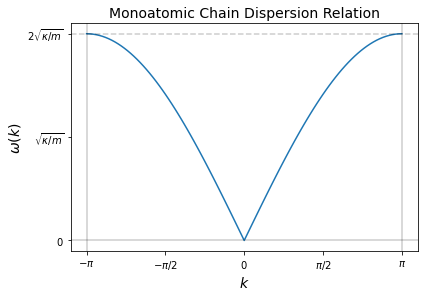

In [3]:
kgrid = np.linspace(-np.pi, np.pi, 101)

plt.figure()

plt.plot(kgrid, mono_w(kgrid))

fs = 14
plt.xlabel(r'$k$', fontsize=fs)
plt.ylabel(r'$\omega(k)$', fontsize=fs)

plt.axhline(0, color = 'k', alpha = 0.2)
plt.axhline(2, color = 'k', alpha = 0.2, linestyle = '--')

plt.axvline(-np.pi, color = 'k', alpha = 0.2)
#plt.axvline(0, color = 'k', alpha = 0.2)
plt.axvline(np.pi, color = 'k', alpha = 0.2)

plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
plt.yticks([0,1, 2], [r'$0$',r'$\sqrt{\kappa/m}$', r'$2\sqrt{\kappa/m}$'])

plt.tight_layout()
plt.title('Monoatomic Chain Dispersion Relation', fontsize = fs)

plt.show()

It can be difficult to visualize the phonon modes the first time you encounter them. Use the following interactive plot to explore what kind of atomic motion you get for different values of $k$.

In [4]:
fig_out1 = widgets.Output()

N = 12  # Number of atoms
nvals = np.arange(N)
ndense = np.linspace(nvals[0], nvals[-1], 1001)
kvals = 2*np.pi/N*np.array([i for i in range(-N//2, N//2+1)])  # Include redundant mode at right BZ boundary
kdense = np.linspace(-np.pi, np.pi, 1001)

# Create widgets
kvec = widgets.FloatSlider(
    value=kvals[N//2], min=-np.pi, max=np.pi, step=2*np.pi/len(nvals),
    description="$k/a$"
)

time = widgets.FloatSlider(
    value=0, min=0, max=50, step=0.1,
    description="$t$"
)

def render1(change=None):
    t = time.value
    k = kvec.value

    y_discrete = displacement(nvals, k, t)
    y_dense = displacement(ndense, k, t)

    with fig_out1:
        fig_out1.clear_output(wait=True)

        fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4), width_ratios=[5, 3])

        ax1.plot(kvals, mono_w(kvals), 'k.')
        ax1.plot(kdense, mono_w(kdense), 'k')
        ax1.plot([k, k], [0, 2], 'r')

        ax0.plot(ndense, y_dense, lw=2)
        ax0.plot(nvals, y_discrete, 'ko')

        fs = 14
        ax0.set_xticks(nvals)
        ax0.set_xlabel(r'$x^{eq}/a$', fontsize=fs)
        ax0.set_ylabel(r'$\delta x$', fontsize=fs)
        ax0.set_ylim(-1.1, 1.1)
        
        ax0.set_yticks([-1,0, 1], [r'$-A$',r'$0$', r'$A$'])
        
        ax1.set_xlabel(r'$k/a$', fontsize=fs)
        ax1.set_ylabel(r'$\omega (k)$', fontsize=fs)
        
        ax1.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
        ax1.set_yticks([0,1, 2], [r'$0$',r'$\sqrt{\kappa/m}$', r'$2\sqrt{\kappa/m}$'])

        plt.tight_layout()
        plt.show()

kvec.observe(render1, names="value")
time.observe(render1, names="value")

display(kvec, time, fig_out1)
render1()

FloatSlider(value=0.0, description='$k/a$', max=3.141592653589793, min=-3.141592653589793, step=0.523598775598…

FloatSlider(value=0.0, description='$t$', max=50.0)

Output()

The reciprocal lattice vectors of this 1D chain are given by $G_m = m \frac{2\pi}{a}$ for integer $m$. It is obvious from the periodicity of the dispersion relation $\omega(k)$ that the phonon modes with wavevectors $k$ and $k+G_m$ have identical frequencies. The connection between the two modes is actually much stronger than this - they are **completely identical** in every way.

The previous statement is counterintuitive. Even if the angular frequency is unaffected, changing the value of $k$ clearly does something to the function $e^{i\omega t - ikx}$. But the before and after functions don't need to agree for all values of $x$ - they only need to agree about what happens at the discrete values $x=x_n^{eq}$, and there turn out to be multiple different waves that result in the same atomic motion. 

This concept of two different waves appearing identical when sampled discretely is known as **aliasing**. It is the reason that fast moving things like vehicle rims or helicopter blades appear to move slowly and/or backwards when filmed at a relatively slow frame rate. 

In [5]:
fig_out2 = widgets.Output()

N = 10  # Number of atoms
nvals = np.arange(N)
ndense = np.linspace(nvals[0], nvals[-1], 1001)

# Create widgets
kvec2 = widgets.FloatSlider(
    value=1, min=-np.pi, max=np.pi, step=2*np.pi/len(nvals),
    description="$k/a$"
)

time2 = widgets.FloatSlider(
    value=0, min=0, max=50, step=0.1,
    description="$t$"
)

def render2(change=None):
    t = time2.value
    k = kvec2.value

    y_discrete = displacement(nvals, k, t)
    y1 = displacement(ndense, k, t)
    y2 = displacement(ndense, k - 2*np.pi, t)

    with fig_out2:
        fig_out2.clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(8, 4))

        ax.plot(ndense, y1, lw=2, color='b')
        ax.plot(ndense, y2, lw=2, color='r')
        ax.plot(nvals, y_discrete, 'ko')
        
        ax.set_xticks(nvals)
        ax.set_xlabel(r'$x^{eq}/a$', fontsize=fs)
        ax.set_ylabel(r'$\delta x$', fontsize=fs)
        ax.set_ylim(-1.1, 1.1)
        
        ax.set_yticks([-1,0, 1], [r'$-A$',r'$0$', r'$A$'])
    

        plt.tight_layout()
        plt.show()

kvec2.observe(render2, names="value")
time2.observe(render2, names="value")

display(kvec2, time2, fig_out2)
render2()


FloatSlider(value=1.0, description='$k/a$', max=3.141592653589793, min=-3.141592653589793, step=0.628318530717…

FloatSlider(value=0.0, description='$t$', max=50.0)

Output()